In [1]:
#Name:Sat Naing Tun  Student_ID:st125333

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import fashion_mnist

(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()
train_images = train_images.astype("float32") / 255
test_images = test_images.astype("float32") / 255

print(train_images.shape)


(60000, 28, 28)


In [2]:
model = keras.Sequential([
layers.Flatten(input_shape=(28,28)),
layers.Dense(512, activation="relu"),
layers.Dense(10, activation="softmax")
])
model.compile(optimizer="adam",

loss="sparse_categorical_crossentropy",
metrics=["accuracy"])

model.fit(train_images, train_labels, epochs=10, batch_size=64, validation_split=0.2)


Epoch 1/10


C:\Users\satna\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7762 - loss: 0.6327 - val_accuracy: 0.8296 - val_loss: 0.4582
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8601 - loss: 0.3820 - val_accuracy: 0.8727 - val_loss: 0.3619
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8782 - loss: 0.3385 - val_accuracy: 0.8742 - val_loss: 0.3478
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8862 - loss: 0.3116 - val_accuracy: 0.8804 - val_loss: 0.3270
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8904 - loss: 0.2884 - val_accuracy: 0.8845 - val_loss: 0.3263
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8999 - loss: 0.2705 - val_accuracy: 0.8867 - val_loss: 0.3148
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9022 - loss: 0.2572 - val_accuracy: 0.8887 - val_loss: 0.3126
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9090 - loss: 0.2444 - val_accuracy: 0.8822 - val_

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


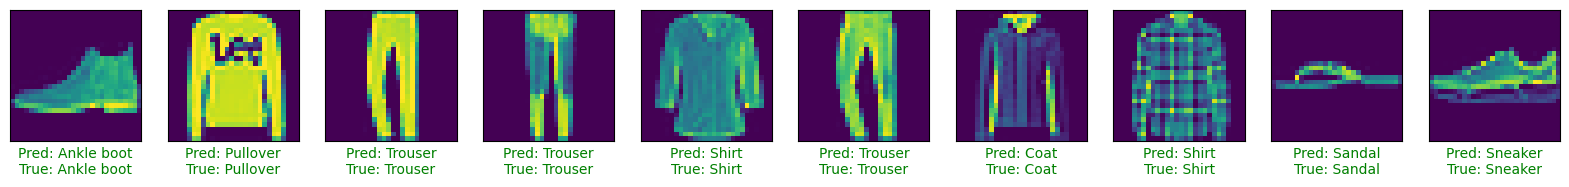

313/313 - 0s - 1ms/step - accuracy: 0.8827 - loss: 0.3371

Final test accuracy: 0.8827


In [3]:
import matplotlib.pyplot as plt
import numpy as np
(train_images_ori, train_labels_ori), (test_images_ori, test_labels_ori) =fashion_mnist.load_data()
test_digits = test_images[0:10]
predictions = model.predict(test_digits)
plt.figure(figsize=(20, 4))
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat','Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
for i in range(10):
  plt.subplot(1, 10, i+1)
  plt.imshow(test_images_ori[i])
  plt.xticks([])
  plt.yticks([])
  predicted_label_index = np.argmax(predictions[i])
  true_label_index = test_labels[i]
  predicted_class = class_names[predicted_label_index]
  true_class = class_names[true_label_index]
  color = 'green' if predicted_label_index == true_label_index else 'red'
  plt.xlabel(f"Pred: {predicted_class}\nTrue: {true_class}", color=color)
plt.show()
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print(f"\nFinal test accuracy: {test_acc:.4f}")